In [1]:
from math import atan, cos, degrees, radians
import forallpeople
import pandas as pd
import handcalcs.render
forallpeople.environment('structural', top_level=True)

# NBCC-15 Static wind load procedure for low buildings
From NBCC-15 Cl. 4.1.7.6., applies to buildings where:
* Total height is less than 20 m and is less than the building width (smaller plan dimension)


## Building Geometry

In [80]:
%%render params
w_bldg =  60*ft # short dimension
l_bldg = 200*ft # long dimension
h_bldg = 51*ft # total height
h_eave = 48*ft # Floor below roof
slope = atan(0/12) # radians
slope_deg = degrees(slope) # degrees
l_overhang = 0*ft

<IPython.core.display.Latex object>

In [81]:
%%render long
z = max(min(0.10 * w_bldg, 0.40 * h_bldg),  0.04*w_bldg) # Cl. 4.1.7.6.-A (7)
y = max(6*m, 2*z).to('ft') # Cl. 4.1.7.6.-A (6)

<IPython.core.display.Latex object>

In [82]:
%%render
height = h_eave
side = l_bldg - 2*y
gable = w_bldg - 2*z
depth = (w_bldg / 2) / cos(slope) + l_overhang / cos(slope)

<IPython.core.display.Latex object>

## NBCC Parameters

In [83]:
%%render params
I_w = 1.0
q = 0.40 * kPa # Design Brief
h_ref = h_bldg + (h_bldg - h_eave)/2
C_e = max(0.7, 0.7*((h_ref/(12*m))**0.3)) # Rough terrain


<IPython.core.display.Latex object>

## Wind Case A

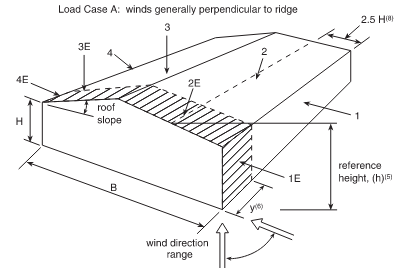

### Areas

In [84]:
%%render
A_1 = height * side
A_1E = height *2* y
A_2 = depth * side
A_2E = depth * 2*y
A_3 = depth * side
A_3E = depth * 2*y
A_4 = height * side
A_4E = height * 2 * y

<IPython.core.display.Latex object>

## Loading

In [85]:
wind_case_A = pd.DataFrame(
    data={"Side": ["1", "1E", "2", "2E", "3", "3E", "4", "4E"], 
          "CpCg": [1, 1.5, -1.3, -2, -0.90,-1.3, -0.8, -1.2], # These values vary with roof angle
          "Area": [
                A_1,
                A_1E,
                A_2,
                A_2E,
                A_3,
                A_3E,
                A_4,
                A_4E,
          ]
         },
)
wind_case_A["IwULS"] = I_w
wind_case_A["IwSLS"] = I_w * 0.75
wind_case_A["q_50"] = q
wind_case_A["Ce"] = C_e
wind_case_A['q_ULS'] = wind_case_A['CpCg'] *  wind_case_A["IwULS"] *  wind_case_A["q_50"] *  wind_case_A["Ce"]
wind_case_A['q_SLS'] = wind_case_A['CpCg'] *  wind_case_A["IwSLS"] *  wind_case_A["q_50"] *  wind_case_A["Ce"]
wind_case_A["Force, SLS"] = wind_case_A["Area"] * wind_case_A["q_SLS"]
wind_case_A['ULS'] = wind_case_A['CpCg'] * I_w * (q) * C_e 
wind_case_A["Force, ULS"] = wind_case_A["Area"] * wind_case_A["q_ULS"]
wind_case_A

,Side,CpCg,Area,IwULS,IwSLS,q_50,Ce,q_ULS,q_SLS,"Force, SLS",ULS,"Force, ULS"
0,1,1.0,7710.236 ft²,1.0,0.75,400.000 Pa,0.763125,305.250 Pa,228.938 Pa,163.989 kN,305.250 Pa,218.652 kN
1,1E,1.5,1889.764 ft²,1.0,0.75,400.000 Pa,0.763125,457.875 Pa,343.406 Pa,60.290 kN,457.875 Pa,80.387 kN
2,2,-1.3,4818.898 ft²,1.0,0.75,400.000 Pa,0.763125,-396.825 Pa,-297.619 Pa,-133.241 kN,-396.825 Pa,-177.655 kN
3,2E,-2.0,1181.102 ft²,1.0,0.75,400.000 Pa,0.763125,-610.500 Pa,-457.875 Pa,-50.242 kN,-610.500 Pa,-66.989 kN
4,3,-0.9,4818.898 ft²,1.0,0.75,400.000 Pa,0.763125,-274.725 Pa,-206.044 Pa,-92.244 kN,-274.725 Pa,-122.992 kN
5,3E,-1.3,1181.102 ft²,1.0,0.75,400.000 Pa,0.763125,-396.825 Pa,-297.619 Pa,-32.657 kN,-396.825 Pa,-43.543 kN
6,4,-0.8,7710.236 ft²,1.0,0.75,400.000 Pa,0.763125,-244.200 Pa,-183.150 Pa,-131.191 kN,-244.200 Pa,-174.922 kN
7,4E,-1.2,1889.764 ft²,1.0,0.75,400.000 Pa,0.763125,-366.300 Pa,-274.725 Pa,-48.232 kN,-366.300 Pa,-64.309 kN


## Wind Case B

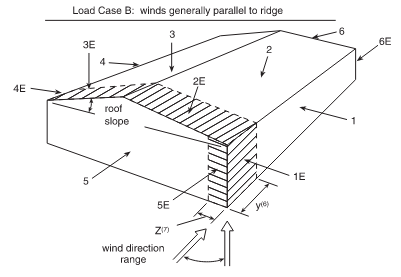

### Areas

In [86]:
%%render
A_1 = height * side
A_1E = height *2* y
A_2 = depth * side
A_2E = depth * 2*y
A_3 = depth * side
A_3E = depth * 2*y
A_4 = height * side
A_4E = height * 2 * y
A_5 = height * gable
A_5E = height * 2*z
A_6 = height * gable
A_6E = height * 2*z

<IPython.core.display.Latex object>

In [87]:
wind_case_B = pd.DataFrame(
    data={"Side": ["1", "1E", "2", "2E", "3", "3E", "4", "4E", "5", "5E", "6", "6E"],
          "CpCg": [-0.85, -0.9, -1.3, -2, -0.70,-1.0, -0.85, -0.9, 0.75, 1.15, -0.55, -0.8], # These values vary
          "Area": [
                    A_1,
                    A_1E,
                    A_2,
                    A_2E,
                    A_3,
                    A_3E,
                    A_4,
                    A_4E,
                    A_5,
                    A_5E,
                    A_6,
                    A_6E,
          ]
         },
)
wind_case_B["IwULS"] = I_w
wind_case_B["IwSLS"] = I_w * 0.75
wind_case_B["q_50"] = q
wind_case_B["Ce"] = C_e
wind_case_B['q_ULS'] = wind_case_B['CpCg'] *  wind_case_B["IwULS"] *  wind_case_B["q_50"] *  wind_case_B["Ce"]
wind_case_B['q_SLS'] = wind_case_B['CpCg'] *  wind_case_B["IwSLS"] *  wind_case_B["q_50"] *  wind_case_B["Ce"]
wind_case_B["Force, SLS"] = wind_case_B["Area"] * wind_case_B["q_SLS"]
wind_case_B['ULS'] = wind_case_B['CpCg'] * I_w * (q) * C_e 
wind_case_B["Force, ULS"] = wind_case_B["Area"] * wind_case_B["q_ULS"]
wind_case_B

,Side,CpCg,Area,IwULS,IwSLS,q_50,Ce,q_ULS,q_SLS,"Force, SLS",ULS,"Force, ULS"
0,1,-0.85,7710.236 ft²,1.0,0.75,400.000 Pa,0.763125,-259.463 Pa,-194.597 Pa,-139.391 kN,-259.463 Pa,-185.854 kN
1,1E,-0.90,1889.764 ft²,1.0,0.75,400.000 Pa,0.763125,-274.725 Pa,-206.044 Pa,-36.174 kN,-274.725 Pa,-48.232 kN
2,2,-1.30,4818.898 ft²,1.0,0.75,400.000 Pa,0.763125,-396.825 Pa,-297.619 Pa,-133.241 kN,-396.825 Pa,-177.655 kN
3,2E,-2.00,1181.102 ft²,1.0,0.75,400.000 Pa,0.763125,-610.500 Pa,-457.875 Pa,-50.242 kN,-610.500 Pa,-66.989 kN
4,3,-0.70,4818.898 ft²,1.0,0.75,400.000 Pa,0.763125,-213.675 Pa,-160.256 Pa,-71.745 kN,-213.675 Pa,-95.660 kN
5,3E,-1.00,1181.102 ft²,1.0,0.75,400.000 Pa,0.763125,-305.250 Pa,-228.938 Pa,-25.121 kN,-305.250 Pa,-33.494 kN
6,4,-0.85,7710.236 ft²,1.0,0.75,400.000 Pa,0.763125,-259.463 Pa,-194.597 Pa,-139.391 kN,-259.463 Pa,-185.854 kN
7,4E,-0.90,1889.764 ft²,1.0,0.75,400.000 Pa,0.763125,-274.725 Pa,-206.044 Pa,-36.174 kN,-274.725 Pa,-48.232 kN
8,5,0.75,2304.000 ft²,1.0,0.75,400.000 Pa,0.763125,228.938 Pa,171.703 Pa,36.753 kN,228.938 Pa,49.004 kN
9,5E,1.15,576.000 ft²,1.0,0.75,400.000 Pa,0.763125,351.038 Pa,263.278 Pa,14.089 kN,351.038 Pa,18.785 kN
